── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Lade nötiges Paket: gsw




COVERAGE COMPARISON
Dates with valid size fractions (strict):     87 / 175 (50%)
Dates with valid size fractions (zero-fill):  176 / 176 (100%)
Dates GAINED by zero-fill:                    89

Dates with absolute biomass (strict):         78
Dates with absolute biomass (zero-fill):      164

Overlapping dates for direct comparison: 87
Saved: comparison_01_scatter_fractions.png

--- Difference statistics (overlapping dates) ---
Mean absolute error in fractions: micro=0.0086, nano=0.0050, pico=0.0069
Max absolute error in fractions:  micro=0.0635, nano=0.0471, pico=0.0756
DP2 mean absolute error: 1.092; mean relative error: 3.2%


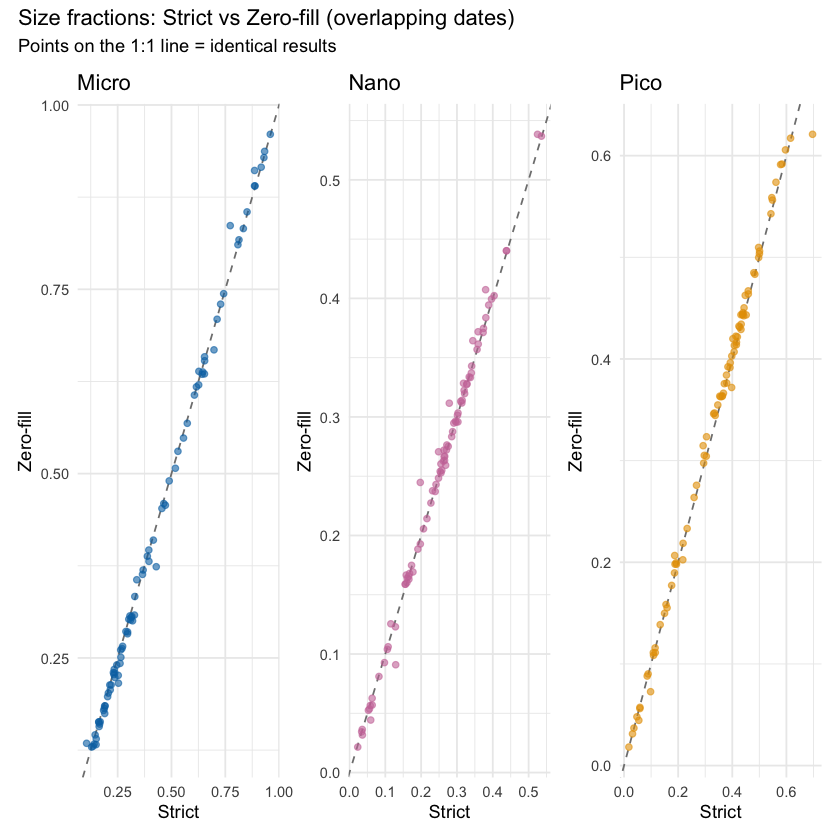

Saved: comparison_02_timeseries_faceted.png


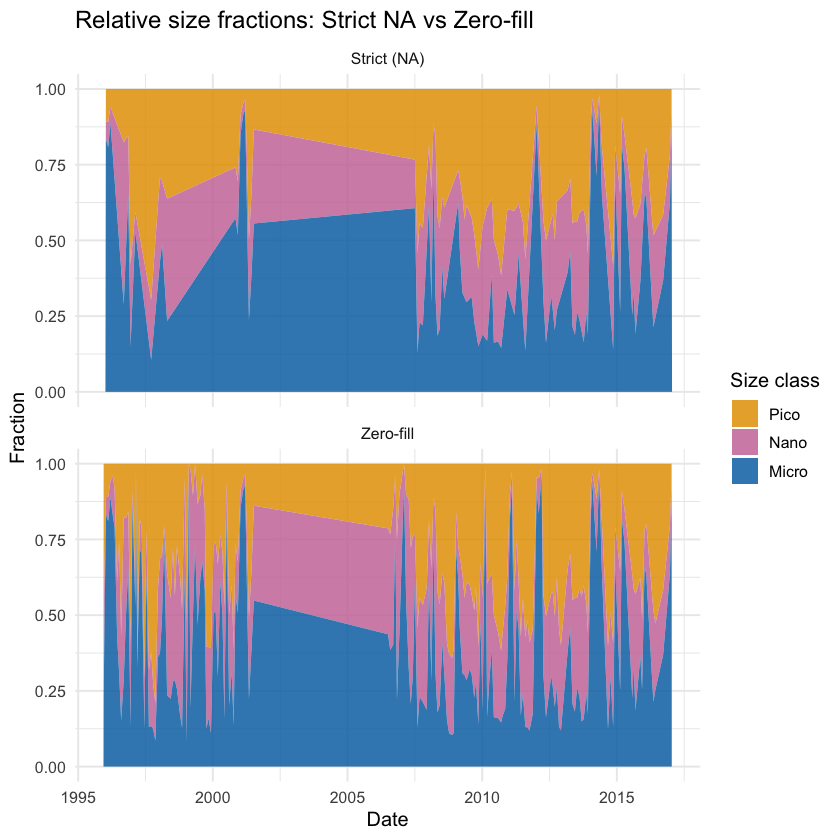

Saved: comparison_03_timeseries_absolute.png

--- 89 gained dates (only available with zero-fill) ---
Size fraction summary for gained dates:
     micro              nano               pico       
 Min.   :0.08129   Min.   :0.002679   Min.   :0.0000  
 1st Qu.:0.16751   1st Qu.:0.161347   1st Qu.:0.1330  
 Median :0.30578   Median :0.272093   Median :0.3275  
 Mean   :0.40236   Mean   :0.264077   Mean   :0.3336  
 3rd Qu.:0.61186   3rd Qu.:0.349605   3rd Qu.:0.5248  
 Max.   :0.96415   Max.   :0.788587   Max.   :0.7920  


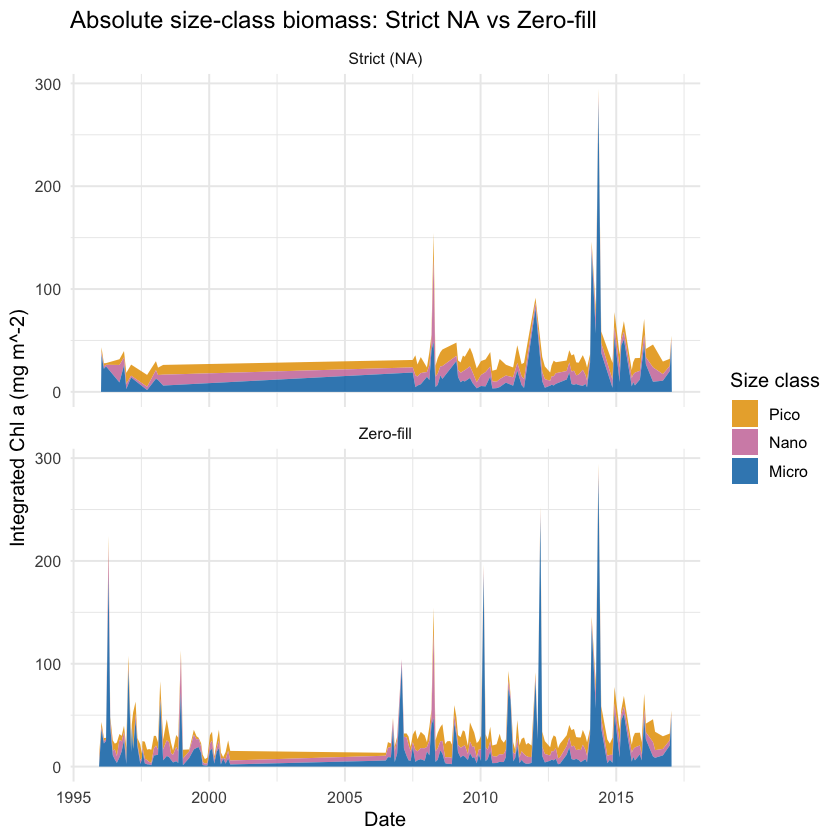

Saved: comparison_04_gained_dates_profile.png


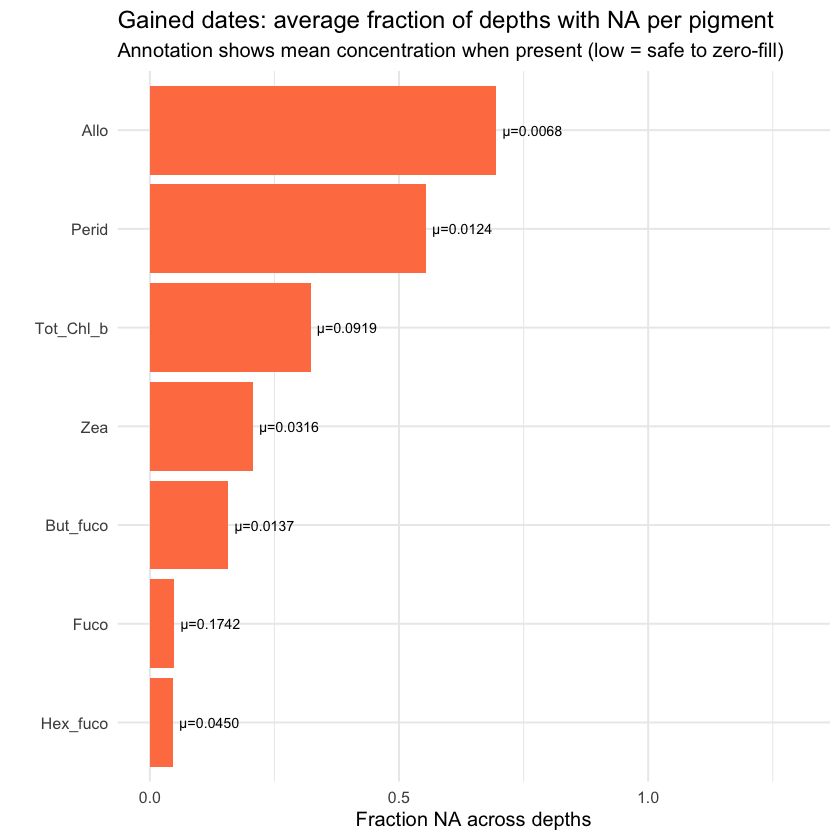

Saved: comparison_05_distributions.png

Done. Review the plots to decide whether zero-fill is acceptable.


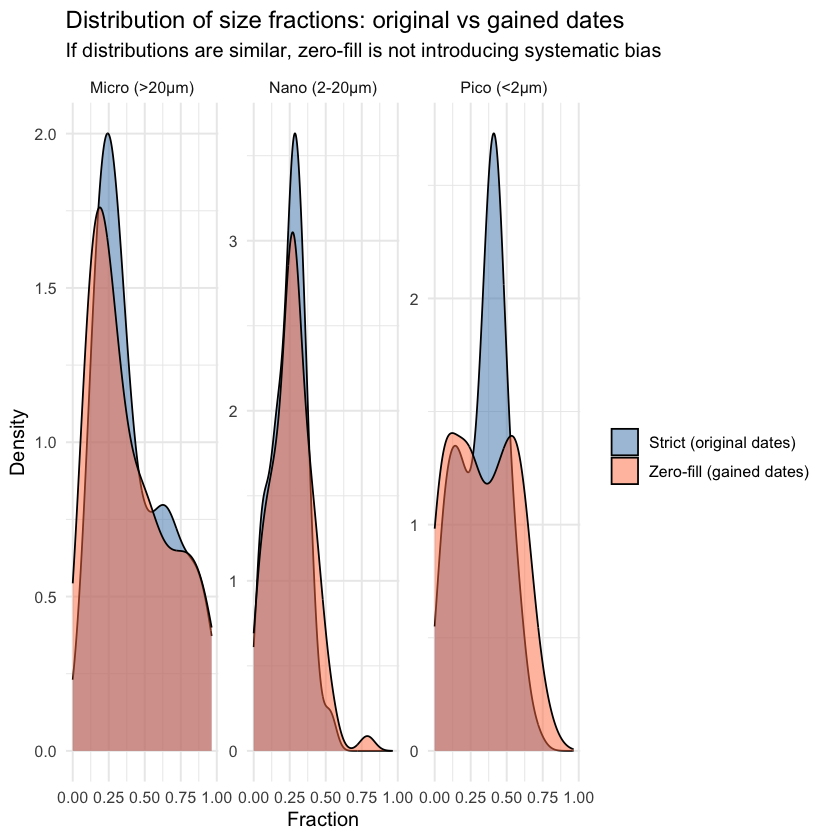

In [1]:
library(tidyverse)
library(patchwork)

# =============================================================================
# 1. LOAD AND PREPARE RAW DATA
# =============================================================================

hplc_bbrs  <- read.csv("../BCO-DMO/hplc_bbrs.csv", na.strings = "nd")
hplc_mote  <- read.csv("../BCO-DMO/hplc_mote.csv", na.strings = "nd")
hplc_hpl   <- read.csv("../BCO-DMO/hplc_hpl.csv", na.strings = "nd")
hplc_ngsfc <- read.csv("../BCO-DMO/hplc_ngsfc.csv", na.strings = "nd")

hplc_bbrs$source  <- "BBRS"
hplc_mote$source  <- "MOTE"
hplc_hpl$source   <- "HPL"
hplc_ngsfc$source <- "NGSFC"

pigments <- c("Pras", "Lut", "Fuco", "Perid", "Allo", "But_fuco",
              "Hex_fuco", "Zea", "Tot_Chl_b", "DP", "Tot_Chl_a",
              "TChl", "Chl_c1c2", "Chl_c3")

dp_pigments <- c("Fuco", "Perid", "Allo", "But_fuco", "Hex_fuco", "Zea", "Tot_Chl_b")

fulldat <- c(pigments, "Date", "depth", "source")

HPLC_ds <- rbind(hplc_bbrs[fulldat],
                 hplc_mote[fulldat],
                 hplc_hpl[fulldat],
                 hplc_ngsfc[fulldat])

HPLC_ds$date <- as.Date(as.character(HPLC_ds$Date), format = "%Y%m%d")
HPLC_ds <- HPLC_ds %>% select(-Date)
HPLC_ds[pigments][HPLC_ds[pigments] < 0] <- NA

source('../interpolateData.r')

# =============================================================================
# 2. INTERPOLATE TWICE: STRICT vs ZERO-FILLED
# =============================================================================

# --- Version A: STRICT (current approach, NA propagates) ---
Mesh_strict <- HPLC_ds %>%
  select(date, depth, all_of(pigments)) %>%
  group_by(date, depth) %>%
  summarise(across(everything(), ~mean(.x, na.rm = TRUE)), .groups = "drop")

hplc_strict <- list()
for (variable in pigments) {
  hplc_strict[[variable]] <- interpolateData(
    Mesh_strict, variable, noofNA = 70, output_type = 'integrated')
  names(hplc_strict[[variable]])[1] <- variable
}
df_strict <- hplc_strict %>% reduce(full_join, by = "date")

# --- Version B: ZERO-FILL DP pigments before interpolation ---
# Only zero-fill the 7 DP pigments; leave others (Tot_Chl_a etc.) as-is
HPLC_ds_zerofill <- HPLC_ds
HPLC_ds_zerofill[dp_pigments][is.na(HPLC_ds_zerofill[dp_pigments])] <- 0

Mesh_zerofill <- HPLC_ds_zerofill %>%
  select(date, depth, all_of(pigments)) %>%
  group_by(date, depth) %>%
  summarise(across(everything(), ~mean(.x, na.rm = TRUE)), .groups = "drop")

hplc_zerofill <- list()
for (variable in pigments) {
  hplc_zerofill[[variable]] <- interpolateData(
    Mesh_zerofill, variable, noofNA = 70, output_type = 'integrated')
  names(hplc_zerofill[[variable]])[1] <- variable
}
df_zerofill <- hplc_zerofill %>% reduce(full_join, by = "date")

# =============================================================================
# 3. COMPUTE SIZE FRACTIONS FOR BOTH
# =============================================================================

compute_size_fractions <- function(df) {
  df %>% mutate(
    DP2 = 1.41 * Fuco + 1.41 * Perid + 0.60 * Allo +
          0.35 * But_fuco + 1.27 * Hex_fuco + 0.86 * Zea + 1.01 * Tot_Chl_b,
    DP2 = ifelse(DP2 < 0.001, NA, DP2),
    micro = (1.41 * Fuco + 1.41 * Perid) / DP2,
    nano  = (0.60 * Allo + 0.35 * But_fuco + 1.27 * Hex_fuco) / DP2,
    pico  = (0.86 * Zea + 1.01 * Tot_Chl_b) / DP2,
    micro_abs = micro * Tot_Chl_a,
    nano_abs  = nano  * Tot_Chl_a,
    pico_abs  = pico  * Tot_Chl_a
  )
}

sf_strict   <- compute_size_fractions(df_strict)   %>% mutate(method = "Strict (NA)")
sf_zerofill <- compute_size_fractions(df_zerofill) %>% mutate(method = "Zero-fill")

# =============================================================================
# 4. COVERAGE COMPARISON
# =============================================================================

cat("\n========================================================\n")
cat("COVERAGE COMPARISON\n")
cat("========================================================\n")

n_strict   <- sum(!is.na(sf_strict$DP2))
n_zerofill <- sum(!is.na(sf_zerofill$DP2))
n_strict_abs   <- sum(!is.na(sf_strict$micro_abs))
n_zerofill_abs <- sum(!is.na(sf_zerofill$micro_abs))

cat(sprintf("Dates with valid size fractions (strict):     %d / %d (%.0f%%)\n",
            n_strict, nrow(sf_strict), 100 * n_strict / nrow(sf_strict)))
cat(sprintf("Dates with valid size fractions (zero-fill):  %d / %d (%.0f%%)\n",
            n_zerofill, nrow(sf_zerofill), 100 * n_zerofill / nrow(sf_zerofill)))
cat(sprintf("Dates GAINED by zero-fill:                    %d\n", n_zerofill - n_strict))
cat(sprintf("\nDates with absolute biomass (strict):         %d\n", n_strict_abs))
cat(sprintf("Dates with absolute biomass (zero-fill):      %d\n", n_zerofill_abs))
cat("========================================================\n")

# =============================================================================
# 5. DIRECT COMPARISON ON OVERLAPPING DATES
# =============================================================================

# Merge on dates where BOTH methods produce valid fractions
overlap <- inner_join(
  sf_strict   %>% filter(!is.na(DP2)) %>% select(date, micro, nano, pico, DP2, micro_abs, nano_abs, pico_abs),
  sf_zerofill %>% filter(!is.na(DP2)) %>% select(date, micro, nano, pico, DP2, micro_abs, nano_abs, pico_abs),
  by = "date", suffix = c(".strict", ".zerofill")
)

cat(sprintf("\nOverlapping dates for direct comparison: %d\n", nrow(overlap)))

# --- Plot 5a: Scatter — fraction comparison ---
p_micro <- ggplot(overlap, aes(x = micro.strict, y = micro.zerofill)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey50") +
  geom_point(alpha = 0.6, color = "#0072B2") +
  labs(title = "Micro", x = "Strict", y = "Zero-fill") +
  theme_minimal(base_size = 11)

p_nano <- ggplot(overlap, aes(x = nano.strict, y = nano.zerofill)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey50") +
  geom_point(alpha = 0.6, color = "#CC79A7") +
  labs(title = "Nano", x = "Strict", y = "Zero-fill") +
  theme_minimal(base_size = 11)

p_pico <- ggplot(overlap, aes(x = pico.strict, y = pico.zerofill)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey50") +
  geom_point(alpha = 0.6, color = "#E69F00") +
  labs(title = "Pico", x = "Strict", y = "Zero-fill") +
  theme_minimal(base_size = 11)

p_scatter_row <- p_micro + p_nano + p_pico +
  plot_annotation(title = "Size fractions: Strict vs Zero-fill (overlapping dates)",
                  subtitle = "Points on the 1:1 line = identical results")

print(p_scatter_row)
#ggsave("comparison_01_scatter_fractions.png", p_scatter_row, width = 13, height = 4.5, dpi = 150)
cat("Saved: comparison_01_scatter_fractions.png\n")

# --- Numeric summary of differences ---
diff_stats <- overlap %>%
  summarise(
    micro_MAE = mean(abs(micro.strict - micro.zerofill)),
    nano_MAE  = mean(abs(nano.strict  - nano.zerofill)),
    pico_MAE  = mean(abs(pico.strict  - pico.zerofill)),
    micro_max_diff = max(abs(micro.strict - micro.zerofill)),
    nano_max_diff  = max(abs(nano.strict  - nano.zerofill)),
    pico_max_diff  = max(abs(pico.strict  - pico.zerofill)),
    DP2_MAE = mean(abs(DP2.strict - DP2.zerofill)),
    DP2_rel_MAE = mean(abs(DP2.strict - DP2.zerofill) / DP2.strict) * 100
  )

cat("\n--- Difference statistics (overlapping dates) ---\n")
cat(sprintf("Mean absolute error in fractions: micro=%.4f, nano=%.4f, pico=%.4f\n",
            diff_stats$micro_MAE, diff_stats$nano_MAE, diff_stats$pico_MAE))
cat(sprintf("Max absolute error in fractions:  micro=%.4f, nano=%.4f, pico=%.4f\n",
            diff_stats$micro_max_diff, diff_stats$nano_max_diff, diff_stats$pico_max_diff))
cat(sprintf("DP2 mean absolute error: %.3f; mean relative error: %.1f%%\n",
            diff_stats$DP2_MAE, diff_stats$DP2_rel_MAE))

# =============================================================================
# 6. TIME SERIES COMPARISON — BOTH METHODS OVERLAID
# =============================================================================

# Stack both methods for plotting
sf_both <- bind_rows(sf_strict, sf_zerofill)

sf_both_long <- sf_both %>%
  filter(!is.na(micro)) %>%
  select(date, micro, nano, pico, method) %>%
  pivot_longer(cols = c(micro, nano, pico), names_to = "size_class", values_to = "fraction") %>%
  mutate(size_class = factor(size_class, levels = c("pico", "nano", "micro"),
                             labels = c("Pico", "Nano", "Micro")))

# Stacked area per method, faceted
p_ts_compare <- sf_both_long %>%
  ggplot(aes(x = date, y = fraction, fill = size_class)) +
  geom_area(position = "stack", alpha = 0.85) +
  facet_wrap(~method, ncol = 1) +
  scale_fill_manual(values = c("Pico" = "#E69F00", "Nano" = "#CC79A7", "Micro" = "#0072B2")) +
  labs(title = "Relative size fractions: Strict NA vs Zero-fill",
       x = "Date", y = "Fraction", fill = "Size class") +
  theme_minimal(base_size = 12)

print(p_ts_compare)
#ggsave("comparison_02_timeseries_faceted.png", p_ts_compare, width = 13, height = 7, dpi = 150)
cat("Saved: comparison_02_timeseries_faceted.png\n")

# --- Absolute biomass comparison ---
sf_abs_long <- sf_both %>%
  filter(!is.na(micro_abs)) %>%
  select(date, micro_abs, nano_abs, pico_abs, method) %>%
  pivot_longer(cols = c(micro_abs, nano_abs, pico_abs), 
               names_to = "size_class", values_to = "chl_a") %>%
  mutate(size_class = factor(size_class, levels = c("pico_abs", "nano_abs", "micro_abs"),
                             labels = c("Pico", "Nano", "Micro")))

p_ts_abs_compare <- sf_abs_long %>%
  ggplot(aes(x = date, y = chl_a, fill = size_class)) +
  geom_area(position = "stack", alpha = 0.85) +
  facet_wrap(~method, ncol = 1) +
  scale_fill_manual(values = c("Pico" = "#E69F00", "Nano" = "#CC79A7", "Micro" = "#0072B2")) +
  labs(title = "Absolute size-class biomass: Strict NA vs Zero-fill",
       x = "Date", y = "Integrated Chl a (mg m^-2)", fill = "Size class") +
  theme_minimal(base_size = 12)

print(p_ts_abs_compare)
#ggsave("comparison_03_timeseries_absolute.png", p_ts_abs_compare, width = 13, height = 7, dpi = 150)
cat("Saved: comparison_03_timeseries_absolute.png\n")

# =============================================================================
# 7. DATES ONLY AVAILABLE IN ZERO-FILL: WHAT DO THEY LOOK LIKE?
# =============================================================================

# These are the dates we GAIN — are the size fractions reasonable?
gained_dates <- sf_zerofill %>%
  filter(!is.na(DP2)) %>%
  filter(!date %in% (sf_strict %>% filter(!is.na(DP2)) %>% pull(date)))

cat(sprintf("\n--- %d gained dates (only available with zero-fill) ---\n", nrow(gained_dates)))
cat("Size fraction summary for gained dates:\n")
gained_dates %>%
  select(micro, nano, pico) %>%
  summary() %>%
  print()

# Check: which DP pigments were zero-filled on these gained dates?
# Look at the raw data for those dates
gained_raw_check <- HPLC_ds %>%
  filter(date %in% gained_dates$date) %>%
  select(date, depth, all_of(dp_pigments)) %>%
  pivot_longer(cols = all_of(dp_pigments), names_to = "pigment", values_to = "value") %>%
  group_by(date, pigment) %>%
  summarise(n_obs = n(),
            n_NA = sum(is.na(value)),
            frac_NA = n_NA / n_obs,
            mean_val = mean(value, na.rm = TRUE),
            .groups = "drop")

# Which pigments are predominantly missing on gained dates?
p_gained_profile <- gained_raw_check %>%
  group_by(pigment) %>%
  summarise(mean_frac_NA = mean(frac_NA),
            mean_val_when_present = mean(mean_val, na.rm = TRUE)) %>%
  mutate(pigment = fct_reorder(pigment, mean_frac_NA)) %>%
  ggplot(aes(x = pigment, y = mean_frac_NA)) +
  geom_col(fill = "coral") +
  geom_text(aes(label = ifelse(is.nan(mean_val_when_present), "always NA",
                                sprintf("µ=%.4f", mean_val_when_present))),
            hjust = -0.1, size = 3) +
  coord_flip() +
  ylim(0, 1.3) +
  labs(title = "Gained dates: average fraction of depths with NA per pigment",
       subtitle = "Annotation shows mean concentration when present (low = safe to zero-fill)",
       x = "", y = "Fraction NA across depths") +
  theme_minimal(base_size = 12)

print(p_gained_profile)
#ggsave("comparison_04_gained_dates_profile.png", p_gained_profile, width = 9, height = 5, dpi = 150)
cat("Saved: comparison_04_gained_dates_profile.png\n")

# =============================================================================
# 8. DISTRIBUTION COMPARISON: are zero-fill fractions biased?
# =============================================================================

# Compare distributions of size fractions: strict-only vs gained-only vs overlap
sf_strict_valid <- sf_strict %>% filter(!is.na(micro)) %>%
  select(date, micro, nano, pico) %>% mutate(group = "Strict (original dates)")

sf_gained_only <- sf_zerofill %>% 
  filter(!is.na(micro), !date %in% sf_strict_valid$date) %>%
  select(date, micro, nano, pico) %>% mutate(group = "Zero-fill (gained dates)")

dist_compare <- bind_rows(sf_strict_valid, sf_gained_only) %>%
  pivot_longer(cols = c(micro, nano, pico), names_to = "size_class", values_to = "fraction") %>%
  mutate(size_class = factor(size_class, levels = c("micro", "nano", "pico"),
                             labels = c("Micro (>20µm)", "Nano (2-20µm)", "Pico (<2µm)")))

p_dist <- ggplot(dist_compare, aes(x = fraction, fill = group)) +
  geom_density(alpha = 0.5) +
  facet_wrap(~size_class, scales = "free_y") +
  scale_fill_manual(values = c("Strict (original dates)" = "steelblue",
                               "Zero-fill (gained dates)" = "coral")) +
  labs(title = "Distribution of size fractions: original vs gained dates",
       subtitle = "If distributions are similar, zero-fill is not introducing systematic bias",
       x = "Fraction", y = "Density", fill = "") +
  theme_minimal(base_size = 12)

print(p_dist)
#ggsave("comparison_05_distributions.png", p_dist, width = 13, height = 5, dpi = 150)
cat("Saved: comparison_05_distributions.png\n")

cat("\nDone. Review the plots to decide whether zero-fill is acceptable.\n")

In [4]:
names(sf_zerofill)

[1] "Pras"      "date"      "Lut"       "Fuco"      "Perid"     "Allo"     
 [7] "But_fuco"  "Hex_fuco"  "Zea"       "Tot_Chl_b" "DP"        "Tot_Chl_a"
[13] "TChl"      "Chl_c1c2"  "Chl_c3"    "DP2"       "micro"     "nano"     
[19] "pico"      "micro_abs" "nano_abs"  "pico_abs"  "method"

In [7]:
out_sizefrac = sf_zerofill %>% select('date','micro','nano','pico','micro_abs','nano_abs','pico_abs')

In [9]:
write.csv(out_sizefrac, "out_sizefrac.csv")